# Modelos de Médias Móveis (MA) em Séries Temporais

Um **Processo de Médias Móveis de ordem $q$**, denotado por **MA($q$)**, modela o valor atual de uma série temporal como uma combinação linear dos $q$ termos de erro (ou choques) aleatórios passados, além do termo de erro aleatório atual. Ao contrário dos modelos AR que dependem de valores passados da própria série, os modelos MA dependem dos erros de previsão passados.

### 1.1. Formulação Matemática do MA($q$)

A forma geral de um MA($q$) é:

$$X_t =  \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$$ 

Onde:
- $X_t$: É o valor observado da série temporal no instante $t$.
- $\mu$: É a média da série (se a série é estacionária, essa é sua média).
- $\epsilon_t$: É o termo de **ruído branco** no tempo $t$, com as mesmas propriedades de um processo AR (média zero, variância constante $\sigma^2$, não correlacionado).
- $\theta_1, \theta_2, \dots, \theta_q$: São os **coeficientes das médias móveis**. Eles quantificam a influência de cada erro passado ($\epsilon_{t-k}$) sobre o valor atual da série.

#### Condição de Estacionariedade e Invertibilidade para MA($q$)
Uma propriedade importante dos processos MA($q$) é que eles **são sempre estacionários**, desde que o processo de ruído branco ($\epsilon_t$) seja estacionário (o que é uma premissa por definição). Isso ocorre porque a dependência de $X_t$ se estende apenas a um número finito de termos de erro passados.

No entanto, para que o modelo MA seja **invertível** (uma condição importante para a estimação e para que ele possa ser representado como um processo AR de ordem infinita), as raízes do polinômio MA devem estar fora do círculo unitário. Isso garante que os coeficientes de uma representação AR de ordem infinita decaiam, evitando que a influência dos erros passados exploda.

### 1.2. Identificação da Ordem $q$ de um Processo MA através da FAC e FACP

A determinação da ordem $q$ de um processo MA é feita pela inspeção dos gráficos da Função de Autocorrelação (FAC) e da Função de Autocorrelação Parcial (FACP).

- **Função de Autocorrelação (FAC)**: A FAC de um processo MA($q$) exibe autocorrelações **significativamente diferentes de zero apenas para os primeiros $q$ lags**. A partir do lag $q+1$, as autocorrelações teoricamente são nulas (caem para dentro dos limites de significância). Essa característica de "corte abrupto" (ou *cutoff*) é o principal critério para identificar a ordem $q$ de um modelo MA.
- **Função de Autocorrelação Parcial (FACP)**: A FACP de um processo MA($q$) é caracterizada por um **decaimento gradual**, que pode ser exponencial ou senoidal amortecido, tendendo a zero à medida que o lag aumenta. Não exibe um corte abrupto.

### 1.3. Exemplo: Simulação e Análise de um Processo MA(1) (Coeficiente Positivo)

Vamos simular um processo MA(1) com um coeficiente positivo.

$$X_t = \epsilon_t + 0.7 \epsilon_{t-1}$$ 
Onde $\epsilon_t \sim N(0, 9)$. O coeficiente $\theta_1 = 0.7$ está dentro do círculo unitário, garantindo a invertibilidade.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.tsa.stattools import adfuller, kpss 
from statsmodels.tsa.ar_model import AutoReg 
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from scipy.stats import shapiro

# Configurações globais para melhorar a visualização dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) 
plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette('deep') 

**Simulando os dados**

In [2]:
np.random.seed(789) 
n_obs = 200
errors_ma1_pos = np.random.normal(0, np.sqrt(9), n_obs) # Gerando os termos de erro (ruído branco)
X_ma1_pos = np.zeros(n_obs)
theta1_ma1_pos = 0.7 # Coeficiente MA para o lag 1

# Simulação do processo MA(1)
for i in range(1, n_obs): # Começa do índice 1 para acessar errors_ma1_pos[i-1]
    X_ma1_pos[i] = errors_ma1_pos[i] + theta1_ma1_pos * errors_ma1_pos[i-1]

df_ma1_pos = pd.DataFrame({'Valor': X_ma1_pos, 'Tempo': range(n_obs)})

**Visualizações gráficas**

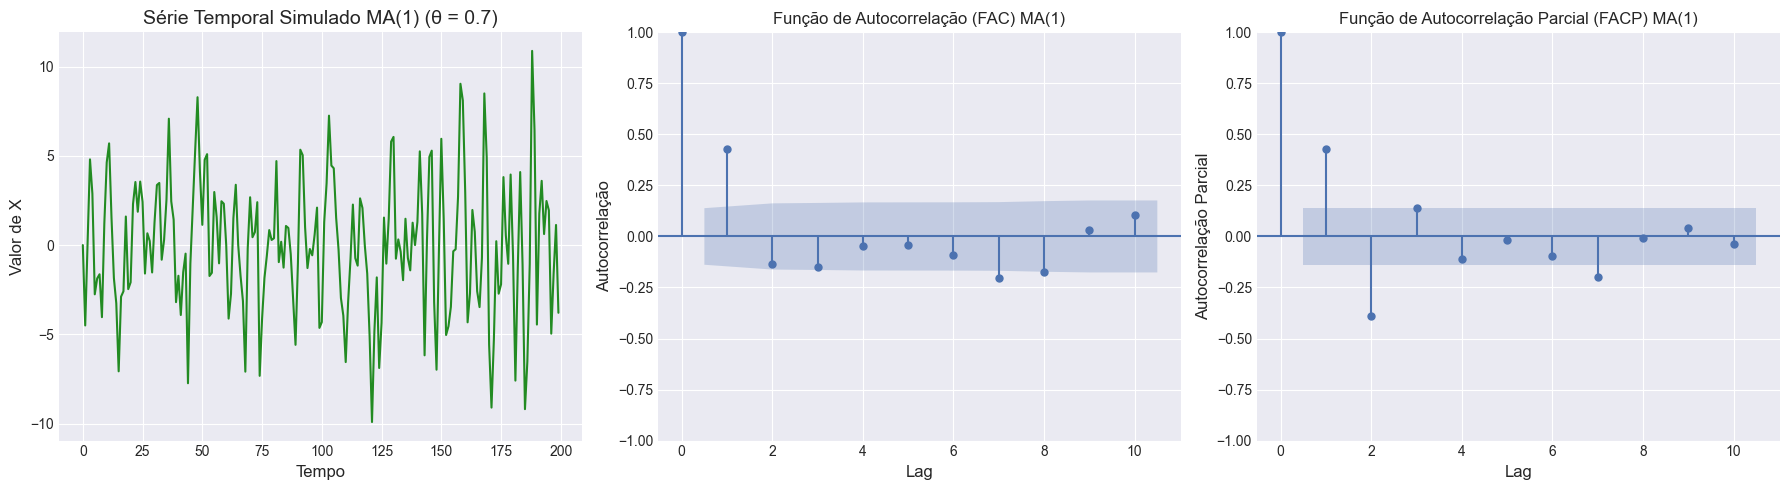

In [3]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.lineplot(data=df_ma1_pos, x='Tempo', y='Valor', color='forestgreen')
plt.title('Série Temporal Simulado MA(1) (θ = 0.7)', fontsize=14)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Valor de X', fontsize=12)

plt.subplot(1, 3, 2)
plot_acf(X_ma1_pos, lags=10, ax=plt.gca(), title='Função de Autocorrelação (FAC) MA(1)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação', fontsize=12)

plt.subplot(1, 3, 3)
plot_pacf(X_ma1_pos, lags=10, ax=plt.gca(), title='Função de Autocorrelação Parcial (FACP) MA(1)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação Parcial', fontsize=12)

plt.tight_layout()
plt.show()


### 2.4. Testes de Estacionariedade para a Série MA(1) (Coeficiente Positivo)

In [4]:
# Executando o Teste KPSS
kpss_result_ma1_pos = kpss(X_ma1_pos, regression='c', nlags='auto')
print('**Teste KPSS para o Processo MA(1) (θ = 0.7) Simulado:**')
print(f'Estatística do Teste: {kpss_result_ma1_pos[0]:.4f}')
print(f'p-valor: {kpss_result_ma1_pos[1]:.4f}')
print('Valores Críticos (Nível de Significância):')
for key, value in kpss_result_ma1_pos[3].items():
    print(f'  {key}: {value:.4f}')
print('\nResultado do KPSS:')
if kpss_result_ma1_pos[1] < 0.05:
    print('Rejeitamos H0: A série NÃO é estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).')


**Teste KPSS para o Processo MA(1) (θ = 0.7) Simulado:**
Estatística do Teste: 0.0722
p-valor: 0.1000
Valores Críticos (Nível de Significância):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Resultado do KPSS:
Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).


C:\Users\p0131335\AppData\Local\Temp\ipykernel_1992\477206021.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_ma1_pos = kpss(X_ma1_pos, regression='c', nlags='auto')


In [5]:
# Executando o Teste ADF
adf_result_ma1_pos = adfuller(X_ma1_pos, autolag='AIC')
print('**Teste ADF para o Processo MA(1) (θ = 0.7) Simulado:**')
print(f'Estatística do Teste: {adf_result_ma1_pos[0]:.4f}')
print(f'p-valor: {adf_result_ma1_pos[1]:.4f}')
print(f'Número de lags usados: {adf_result_ma1_pos[2]}')
print(f'Número de observações usadas para regressão ADF: {adf_result_ma1_pos[3]}')
print('Valores Críticos (Nível de Significância):')
for key, value in adf_result_ma1_pos[4].items():
    print(f'  {key}: {value:.4f}')
print('Resultado do ADF:')
if adf_result_ma1_pos[1] <= 0.05:
    print('Rejeitamos H0: A série É estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série NÃO é estacionária (não significativa no nível de 5%).')

**Teste ADF para o Processo MA(1) (θ = 0.7) Simulado:**
Estatística do Teste: -7.1529
p-valor: 0.0000
Número de lags usados: 6
Número de observações usadas para regressão ADF: 193
Valores Críticos (Nível de Significância):
  1%: -3.4647
  5%: -2.8766
  10%: -2.5748
Resultado do ADF:
Rejeitamos H0: A série É estacionária (significativa no nível de 5%).


**Interpretação dos Resultados para o Processo MA(1) (Coeficiente Positivo):**
- **Série Temporal (Gráfico 1)**: A série exibe flutuações em torno de uma média constante, indicando estacionariedade.
- **Função de Autocorrelação (FAC - Gráfico 2)**: Este gráfico mostra um **pico significativo apenas no lag 1**, e depois as autocorrelações caem abruptamente para dentro dos limites de não significância. O valor da autocorrelação no lag 1 é positivo, refletindo o coeficiente $\theta_1 = 0.7$. Este "corte" no lag 1 é a assinatura de um processo MA(1).
- **Função de Autocorrelação Parcial (FACP - Gráfico 3)**: Observa-se um decaimento gradual das autocorrelações parciais, sem um corte abrupto claro, o que é o padrão esperado para processos MA.
- **Testes de Estacionariedade (KPSS e ADF)**: Ambos os testes devem confirmar que a série MA(1) é estacionária, conforme a teoria (processos MA são intrinsecamente estacionários).

**Verificando um Modelo MA**

In [6]:
MA_model = ARIMA(X_ma1_pos, order=(0, 0, 1)).fit()
E_MA = MA_model.resid

In [7]:
### Análise Gráfica dos Resíduos do Modelo MA

In [8]:
#análise de Resíduos
def plot_acf_pacf(series, lags=10, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].plot(series)
    axes[0].set_title(f'Série Temporal - {title}')
    plot_acf(series, lags=lags, ax=axes[1])
    plot_pacf(series, lags=lags, ax=axes[2])
    plt.tight_layout()
    plt.show()

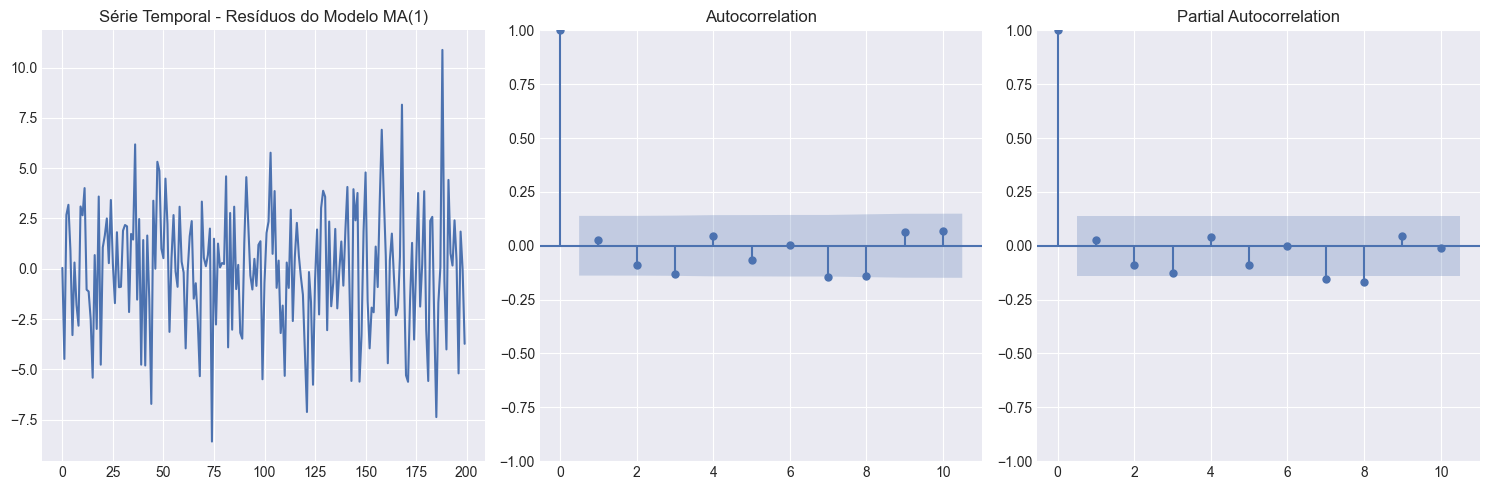

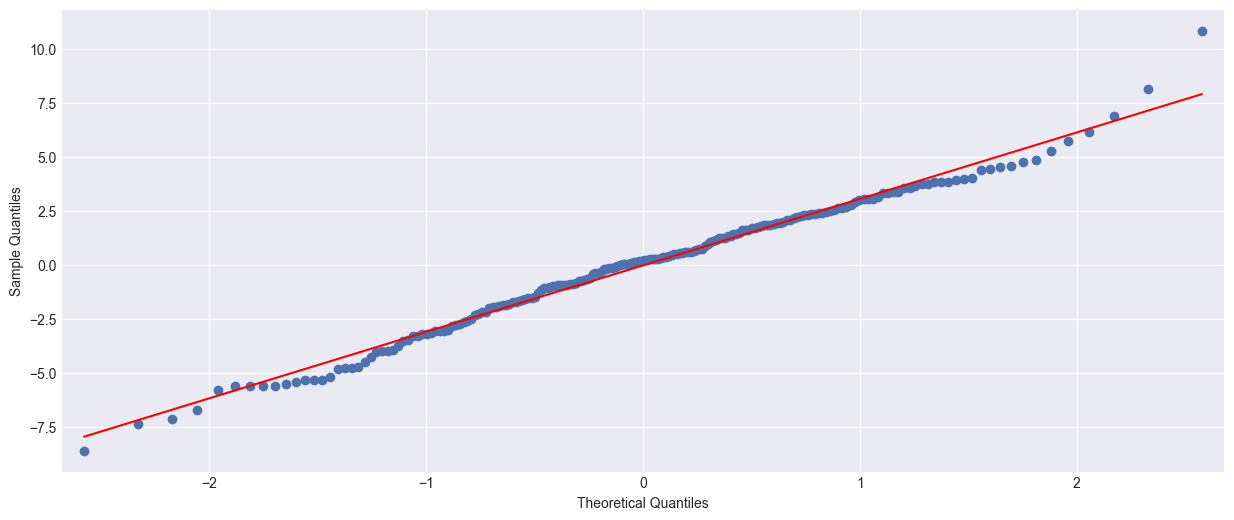

In [9]:
plot_acf_pacf(E_MA, title='Resíduos do Modelo MA(1)')
sm.qqplot(E_MA, line='s')
plt.show()

**Teste de Independência - Ljung-Box**

In [10]:
ljung_box_result = sm.stats.acorr_ljungbox(E_MA, lags=[20], return_df=True)
print('Teste de Independência - Ljung-Box:')
print(ljung_box_result)

Teste de Independência - Ljung-Box:
      lb_stat  lb_pvalue
20  29.641857   0.075868


**Teste de Normalidade - Shapiro-Wilk**

In [11]:
shapiro_stat, shapiro_p_value = shapiro(E_MA)
print('Teste de Normalidade - Shapiro-Wilk:')
print(f'Estatística do teste: {shapiro_stat:.4f}')
print(f'p-valor: {shapiro_p_value:.4f}')

Teste de Normalidade - Shapiro-Wilk:
Estatística do teste: 0.9908
p-valor: 0.2309


### 1.5. Exemplo: Simulação e Análise de um Processo MA(1) (Coeficiente Negativo)

Vamos agora simular um processo MA(1) com um coeficiente negativo para observar como isso afeta os gráficos de autocorrelação.

$$X_t = \epsilon_t - 0.7 \epsilon_{t-1}$$ 
Onde $\epsilon_t \sim N(0, 9)$. O coeficiente $\theta_1 = -0.7$ também garante a invertibilidade.

**Simulando uma Série MA(1) negativa**

In [12]:
np.random.seed(1011) # Nova semente para reprodutibilidade
n_obs = 200
errors_ma1_neg = np.random.normal(0, np.sqrt(9), n_obs)
X_ma1_neg = np.zeros(n_obs)
theta1_ma1_neg = -0.7 # Coeficiente MA negativo

# Simulação do processo MA(1) com coeficiente negativo
for i in range(1, n_obs):
    X_ma1_neg[i] = errors_ma1_neg[i] + theta1_ma1_neg * errors_ma1_neg[i-1]

df_ma1_neg = pd.DataFrame({'Valor': X_ma1_neg, 'Tempo': range(n_obs)})

**Análise Gráfica da Série**

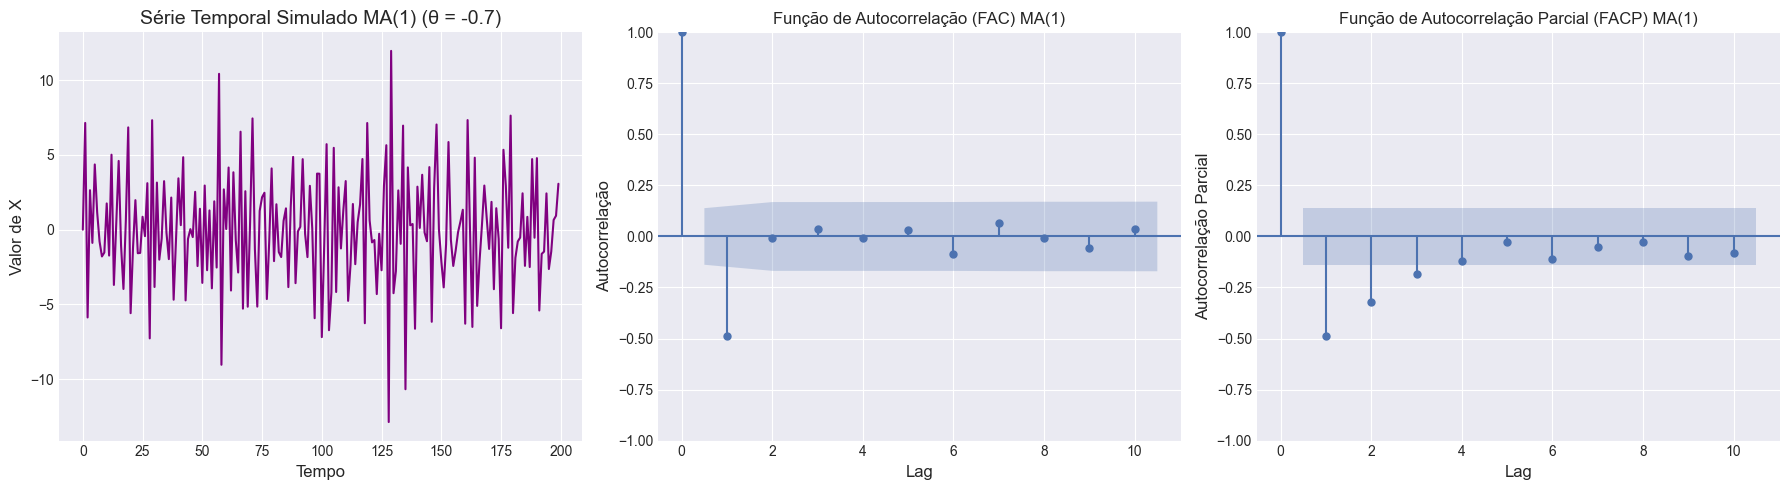

In [13]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.lineplot(data=df_ma1_neg, x='Tempo', y='Valor', color='purple')
plt.title('Série Temporal Simulado MA(1) (θ = -0.7)', fontsize=14)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Valor de X', fontsize=12)

plt.subplot(1, 3, 2)
plot_acf(X_ma1_neg, lags=10, ax=plt.gca(), title='Função de Autocorrelação (FAC) MA(1)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação', fontsize=12)

plt.subplot(1, 3, 3)
plot_pacf(X_ma1_neg, lags=10, ax=plt.gca(), title='Função de Autocorrelação Parcial (FACP) MA(1)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação Parcial', fontsize=12)

plt.tight_layout()
plt.show()


### 1.6. Testes de Estacionariedade para a Série MA(1) (Coeficiente Negativo)

In [14]:
# Executando o Teste KPSS
kpss_result_ma1_neg = kpss(X_ma1_neg, regression='c', nlags='auto')
print('**Teste KPSS para o Processo MA(1) (θ = -0.7) Simulado:**')
print(f'Estatística do Teste: {kpss_result_ma1_neg[0]:.4f}')
print(f'p-valor: {kpss_result_ma1_neg[1]:.4f}')
print('Valores Críticos (Nível de Significância):')
for key, value in kpss_result_ma1_neg[3].items():
    print(f'  {key}: {value:.4f}')
print('\nResultado do KPSS:')
if kpss_result_ma1_neg[1] < 0.05:
    print('Rejeitamos H0: A série NÃO é estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).')


**Teste KPSS para o Processo MA(1) (θ = -0.7) Simulado:**
Estatística do Teste: 0.2049
p-valor: 0.1000
Valores Críticos (Nível de Significância):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Resultado do KPSS:
Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).


C:\Users\p0131335\AppData\Local\Temp\ipykernel_1992\898995959.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_ma1_neg = kpss(X_ma1_neg, regression='c', nlags='auto')


In [15]:
# Executando o Teste ADF
adf_result_ma1_neg = adfuller(X_ma1_neg, autolag='AIC')
print('**Teste ADF para o Processo MA(1) (θ = -0.7) Simulado:**')
print(f'Estatística do Teste: {adf_result_ma1_neg[0]:.4f}')
print(f'p-valor: {adf_result_ma1_neg[1]:.4f}')
print(f'Número de lags usados: {adf_result_ma1_neg[2]}')
print(f'Número de observações usadas para regressão ADF: {adf_result_ma1_neg[3]}')
print('Valores Críticos (Nível de Significância):')
for key, value in adf_result_ma1_neg[4].items():
    print(f'  {key}: {value:.4f}')
print('Resultado do ADF:')
if adf_result_ma1_neg[1] <= 0.05:
    print('Rejeitamos H0: A série É estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série NÃO é estacionária (não significativa no nível de 5%).')

**Teste ADF para o Processo MA(1) (θ = -0.7) Simulado:**
Estatística do Teste: -10.7280
p-valor: 0.0000
Número de lags usados: 3
Número de observações usadas para regressão ADF: 196
Valores Críticos (Nível de Significância):
  1%: -3.4642
  5%: -2.8764
  10%: -2.5747
Resultado do ADF:
Rejeitamos H0: A série É estacionária (significativa no nível de 5%).


**Interpretação dos Resultados para o Processo MA(1) (Coeficiente Negativo):**
- No gráfico da **FAC**, novamente vemos um corte abrupto no **lag 1**, confirmando um MA(1). A diferença agora é que a autocorrelação no lag 1 é **negativa**, refletindo o sinal do coeficiente $\theta_1 = -0.7$.
- No gráfico da **FACP**, observamos o decaimento gradual esperado para processos MA.
- Os **testes de estacionariedade** devem, como esperado, indicar que a série é estacionária.

**Verificando um Modelo MA**

**Teste de Independência - Ljung-Box**

In [16]:
# Verificando um Modelo MA(1)
MA_model = ARIMA(X_ma1_neg, order=(0, 0, 1)).fit()
E_MA = MA_model.resid

**Análise Gráfica dos Resíduos do Modelo MA**

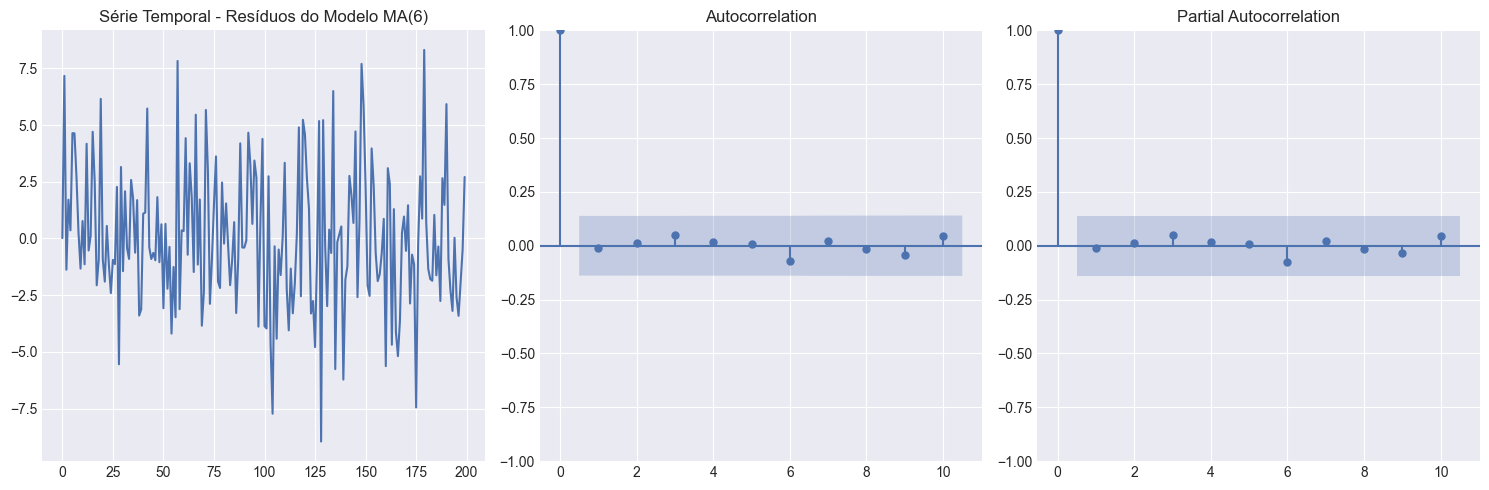

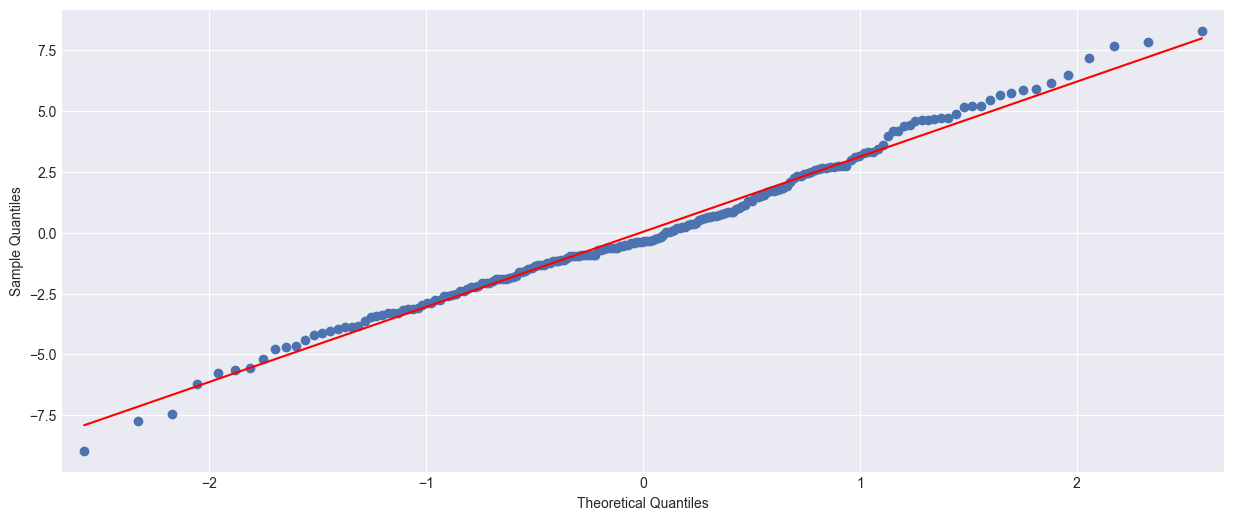

In [17]:
plot_acf_pacf(E_MA, title='Resíduos do Modelo MA(6)')
sm.qqplot(E_MA, line='s')
plt.show()

**Teste de Independência - Ljung-Box**

In [18]:
ljung_box_result = sm.stats.acorr_ljungbox(E_MA, lags=[20], return_df=True)
print('Teste de Independência - Ljung-Box:')
print(ljung_box_result)

Teste de Independência - Ljung-Box:
      lb_stat  lb_pvalue
20  12.753041   0.887727


**Teste de Normalidade - Shapiro-Wilk**

In [19]:
shapiro_stat, shapiro_p_value = shapiro(E_MA)
print('Teste de Normalidade - Shapiro-Wilk:')
print(f'Estatística do teste: {shapiro_stat:.4f}')
print(f'p-valor: {shapiro_p_value:.4f}')

Teste de Normalidade - Shapiro-Wilk:
Estatística do teste: 0.9905
p-valor: 0.2142


### 1.7. Exemplo: Simulação e Análise de um Processo MA(2)

Para finalizar os exemplos de MA, vamos simular um processo MA(2).

$$X_t = \epsilon_t + 0.5 \epsilon_{t-1} - 0.4 \epsilon_{t-2}$$ 
Onde $\epsilon_t \sim N(0, 9)$. Os coeficientes $\theta_1 = 0.5$ e $\theta_2 = -0.4$ foram escolhidos para garantir a invertibilidade.

**Simulando um Processo MA(2)**

In [20]:
np.random.seed(1234) # Nova semente para reprodutibilidade
n_obs = 200
errors_ma2 = np.random.normal(0, np.sqrt(9), n_obs)
X_ma2 = np.zeros(n_obs)
theta1_ma2 = 0.5
theta2_ma2 = -0.4

# Simulação do processo MA(2)
for i in range(2, n_obs): # Começa do índice 2
    X_ma2[i] = errors_ma2[i] + theta1_ma2 * errors_ma2[i-1] + theta2_ma2 * errors_ma2[i-2]

df_ma2 = pd.DataFrame({'Valor': X_ma2, 'Tempo': range(n_obs)})

**Análise Gráfica**

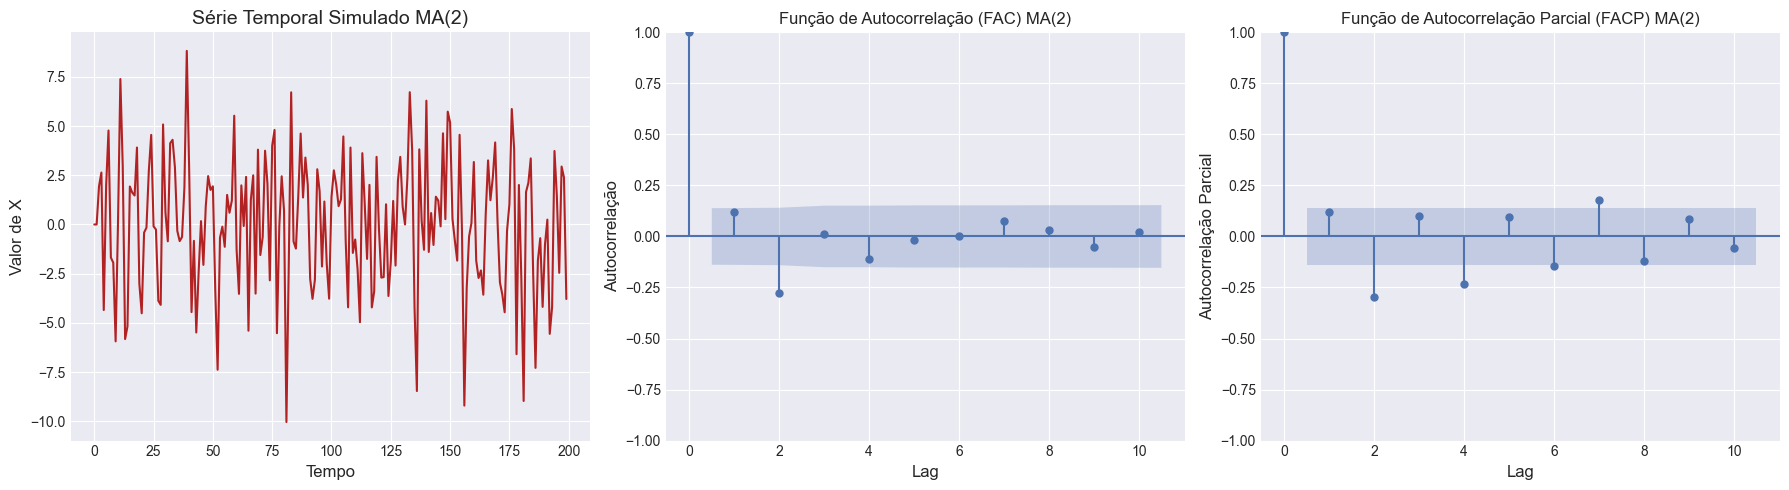

In [21]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.lineplot(data=df_ma2, x='Tempo', y='Valor', color='firebrick')
plt.title('Série Temporal Simulado MA(2)', fontsize=14)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Valor de X', fontsize=12)

plt.subplot(1, 3, 2)
plot_acf(X_ma2, lags=10, ax=plt.gca(), title='Função de Autocorrelação (FAC) MA(2)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação', fontsize=12)

plt.subplot(1, 3, 3)
plot_pacf(X_ma2, lags=10, ax=plt.gca(), title='Função de Autocorrelação Parcial (FACP) MA(2)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação Parcial', fontsize=12)

plt.tight_layout()
plt.show()


### 1.8. Testes de Estacionariedade para a Série MA(2)

In [22]:
# Executando o Teste KPSS
kpss_result_ma2 = kpss(X_ma2, regression='c', nlags='auto')
print('**Teste KPSS para o Processo MA(2) Simulado:**')
print(f'Estatística do Teste: {kpss_result_ma2[0]:.4f}')
print(f'p-valor: {kpss_result_ma2[1]:.4f}')
print('Valores Críticos (Nível de Significância):')
for key, value in kpss_result_ma2[3].items():
    print(f'  {key}: {value:.4f}')
print('\nResultado do KPSS:')
if kpss_result_ma2[1] < 0.05:
    print('Rejeitamos H0: A série NÃO é estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).')


**Teste KPSS para o Processo MA(2) Simulado:**
Estatística do Teste: 0.1916
p-valor: 0.1000
Valores Críticos (Nível de Significância):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Resultado do KPSS:
Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).


C:\Users\p0131335\AppData\Local\Temp\ipykernel_1992\1385483317.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_ma2 = kpss(X_ma2, regression='c', nlags='auto')


In [23]:
# Executando o Teste ADF
adf_result_ma2 = adfuller(X_ma2, autolag='AIC')
print('**Teste ADF para o Processo MA(2) Simulado:**')
print(f'Estatística do Teste: {adf_result_ma2[0]:.4f}')
print(f'p-valor: {adf_result_ma2[1]:.4f}')
print(f'Número de lags usados: {adf_result_ma2[2]}')
print(f'Número de observações usadas para regressão ADF: {adf_result_ma2[3]}')
print('Valores Críticos (Nível de Significância):')
for key, value in adf_result_ma2[4].items():
    print(f'  {key}: {value:.4f}')
print('Resultado do ADF:')
if adf_result_ma2[1] <= 0.05:
    print('Rejeitamos H0: A série É estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série NÃO é estacionária (não significativa no nível de 5%).')

**Teste ADF para o Processo MA(2) Simulado:**
Estatística do Teste: -4.6722
p-valor: 0.0001
Número de lags usados: 11
Número de observações usadas para regressão ADF: 188
Valores Críticos (Nível de Significância):
  1%: -3.4656
  5%: -2.8770
  10%: -2.5750
Resultado do ADF:
Rejeitamos H0: A série É estacionária (significativa no nível de 5%).


**Interpretação dos Resultados para o Processo MA(2):**
- Na **FAC**, observamos que as autocorrelações são significativamente diferentes de zero nos **lags 1 e 2**, e depois há um "corte" abrupto, caindo para dentro dos limites de não significância. Isso é a característica principal de um processo MA de ordem 2.
- Na **FACP**, notamos um decaimento gradual, sem um corte claro, que é o padrão típico para processos MA.
- Os **testes de estacionariedade** devem, novamente, confirmar a estacionariedade da série.

**Validando um Modelo MA**

In [24]:
# Verificando um Modelo MA(2)
MA_model = ARIMA(X_ma2, order=(0, 0, 2)).fit()
E_MA = MA_model.resid

**Análise Gráfica dos Resíduos do Modelo MA**

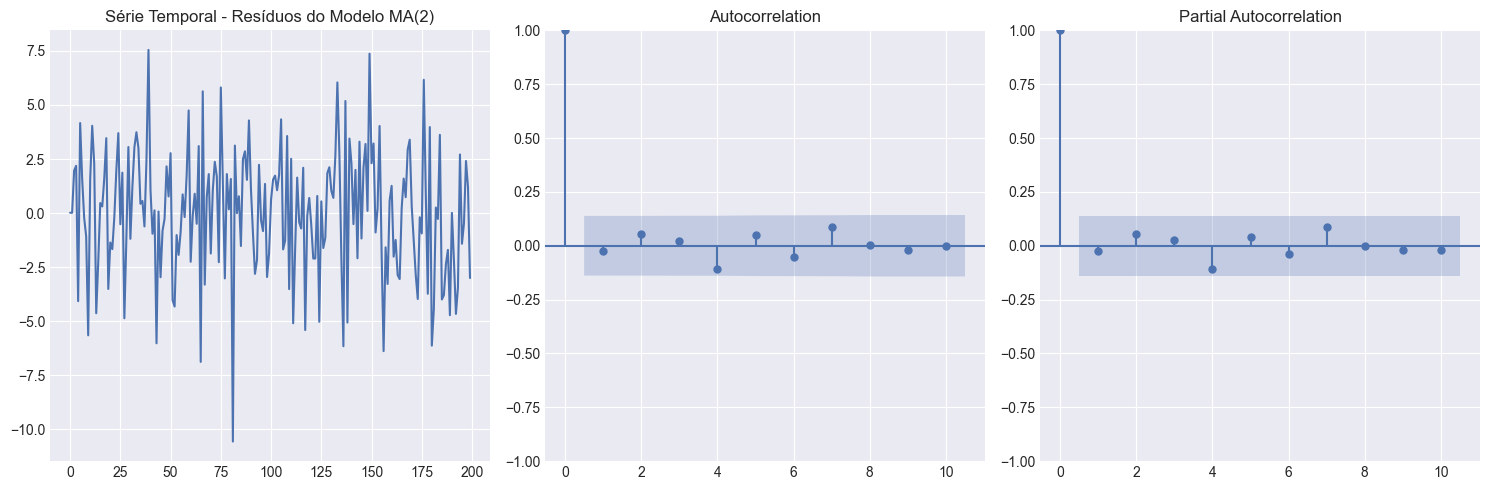

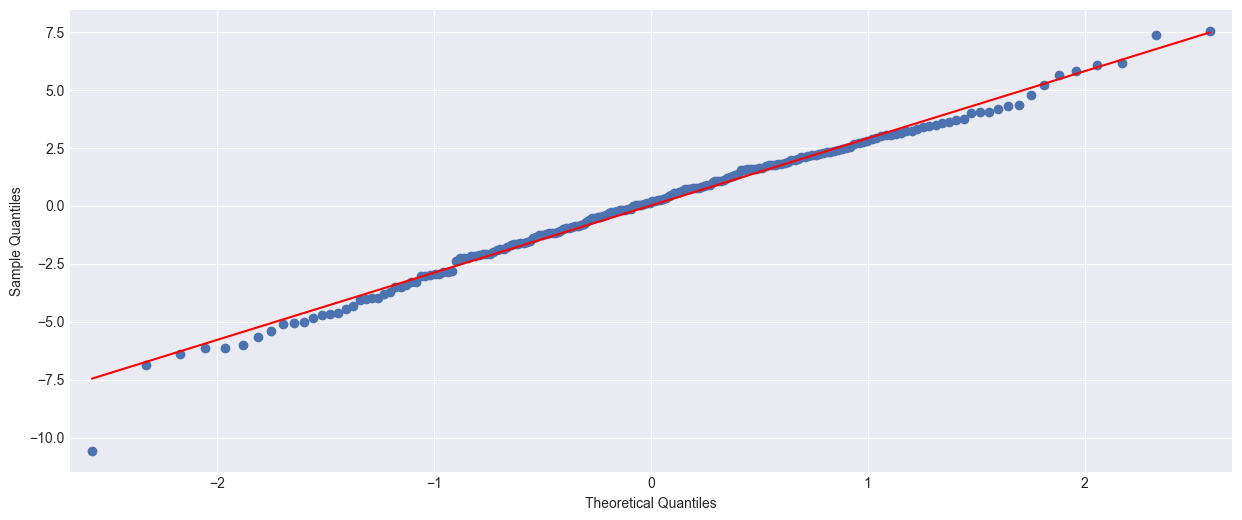

In [25]:
plot_acf_pacf(E_MA, title='Resíduos do Modelo MA(2)')
sm.qqplot(E_MA, line='s')
plt.show()

**Teste de Independência - Ljung-Box**

In [26]:
ljung_box_result = sm.stats.acorr_ljungbox(E_MA, lags=[20], return_df=True)
print('Teste de Independência - Ljung-Box:')
print(ljung_box_result)

Teste de Independência - Ljung-Box:
      lb_stat  lb_pvalue
20  14.079422   0.826446


**Teste de Normalidade - Shapiro-Wilk**

In [27]:
shapiro_stat, shapiro_p_value = shapiro(E_MA)
print('Teste de Normalidade - Shapiro-Wilk:')
print(f'Estatística do teste: {shapiro_stat:.4f}')
print(f'p-valor: {shapiro_p_value:.4f}')

Teste de Normalidade - Shapiro-Wilk:
Estatística do teste: 0.9918
p-valor: 0.3231


## Síntese da Identificação de Modelos AR e MA

Com base nas simulações e nas propriedades teóricas, a identificação da ordem $p$ (para AR) ou $q$ (para MA) em séries temporais estacionárias é guiada pelos padrões nas Funções de Autocorrelação (FAC) e Autocorrelação Parcial (FACP):

- **Para Processos Autorregressivos (AR($p$))**: 
    - A **FAC** exibe um decaimento gradual (exponencial ou senoidal amortecido).
    - A **FACP** tem um **corte abrupto** (ou *cutoff*) após o lag $p$. **Use a FACP para identificar a ordem $p$.**

- **Para Processos de Médias Móveis (MA($q$))**: 
    - A **FAC** tem um **corte abrupto** (ou *cutoff*) após o lag $q$. **Use a FAC para identificar a ordem $q$.**
    - A **FACP** exibe um decaimento gradual (exponencial ou senoidal amortecido).

Essa dicotomia é crucial para a fase de identificação dos modelos ARMA e ARIMA.